# Tag ABM — fixed-weight design

This notebook runs and explores the tag model in `tag_abm.py`. The two
conditions are set to their extreme forms: `CONDITION_WEIGHT_FUN = 1.0`
(self-handicapping fully on) and `CONDITION_WEIGHT_WIN = 0.0` (fully off). Every
other parameter is swept over a sensible range, and we watch what the model
does. Whether FUN produces more tags than WIN, and whether a WIN game stalls,
are left for the model to show; nothing here forces either. In the spirit of
Smaldino (2017), the model is free to fail.

Each parameter set is judged on 100 paired games. A game is two minutes of tag
with five players. For each set we draw 100 groups of five players and play one
FUN game and one WIN game with each group, so the two conditions are always
played by the same players. A set's FUN and WIN tag rates are the averages over
its 100 games in each condition.

The one rule a set has to pass is a sanity check: its average game, in either
condition, may not exceed 60 tags. There is no rule that FUN must beat WIN, and
no minimum number of tags.

**Contents**
1. Setup
2. Design and parameters
3. The sweep
4. The contrast across the region
5. What drives the contrast
6. One example game
7. Taking the luck away
8. Does WIN ever beat FUN in a single game?

Requires `tag_abm.py` in the same directory.

## 1. Setup

In [2]:
import sys
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats as sp_stats

warnings.filterwarnings("ignore")

# tag_abm.py must be in the same directory as this notebook
sys.path.insert(0, os.getcwd())
from tag_abm import run_experiment, TagModel

# ── Visual theme ──────────────────────────────────────────────────────────────
BG         = "#F8F5F0"
DARK       = "#1C1C2E"
MID        = "#5A5A7A"
GRID       = "#E2DDD6"
CENSOR_COL = "#AAAAAA"

# Condition colors match the experiment's plotting notebook (06_Plots.ipynb)
# exactly, so simulated and empirical figures read as one family.
WIN_C = "#648FFF";  WIN_L = "#C7D7FF"
FUN_C = "#DC267F";  FUN_L = "#F5C1DA"
GREEN = "#009E73"   # direction-as-expected (experiment convention)
RED   = "#D55E00"   # direction-against

cm = 1 / 2.54       # figure sizes in cm, as in the experiment notebooks

COND_STYLE = {
    "WIN": {"color": WIN_C, "light": WIN_L},
    "FUN": {"color": FUN_C, "light": FUN_L},
}

CONDITIONS = ["WIN", "FUN"]

P_COLS = [
    "#B5391C",   # P1 — brick red
    "#1B6CA8",   # P2 — steel blue
    "#2E8B57",   # P3 — sea green
    "#CC8800",   # P4 — amber
    "#6A0DAD",   # P5 — deep violet
]

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "axes.edgecolor":   GRID,
    "axes.labelcolor":  MID,
    "xtick.color":      MID,
    "ytick.color":      MID,
    "text.color":       DARK,
    "font.size":        9,
})


def style_ax(ax, title=None):
    # Apply the shared visual theme to one Axes.
    ax.set_facecolor(BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=MID)
    if title:
        ax.set_title(title, fontsize=11, fontweight="bold", color=DARK, pad=8)


def player_number_from_id(player_id):
    # Extract the integer player number from a "<group>_<player>" id string.
    return int(str(player_id).split("_")[1])


print("Setup complete.")

Matplotlib is building the font cache; this may take a moment.


Setup complete.


## 2. Design and parameters

**Fixed parameters.** A game has five players and lasts 120 seconds. The
timestep is half a second; the chase noise is measured per step, so the timestep
stays fixed. How fast the players run is drawn from a normal distribution with
mean 6.0 m/s and standard deviation 0.5 m/s, taken from 30 m sprint times for
11 to 13 year olds (Vandoni et al., 2024). It is a top speed the arousal
mechanism scales down from, not an average. The condition weights are fixed at
1.0 (FUN) and 0.0 (WIN).

**Swept parameters.** Everything else is swept, drawn at random from a range.
Some ranges are physical. `STARTING_DISTANCE` (1.5 to 5 m) is how far ahead the
runner starts; `CATCH_DISTANCE` (0.5 to 2 m) is the reach needed to tag, about
an arm to a lunge. `PURSUIT_NOISE` (0 to 1.5 m) is the random shift in the gap
each step, standing for the turns and luck a straight line misses: a child moves
at most about 3 m in half a second, so even a large jump stays within reach. The
three distances stay in order, catch inside starting inside give-up.

Other parameters have no physical anchor, so each is swept across its whole
working range, from where it does almost nothing to where it does all it can.
`AROUSAL_DECAY_RATE` (0.005 to 0.08) is how fast a runner tires: barely over a
game at the low end, flat within about twelve seconds at the high end.
`AROUSAL_RESTORATION_SWITCH` and `AROUSAL_RESTORATION_TAGGER` (0.1 to 3.0) are
the lift in arousal on a tag, closing from about a tenth up to almost all of the
gap back to full. The tagger's restoration is swept too, since it sets the
arousal a player carries back into being a runner. It is also kept above the
runners' restoration, since becoming the active chaser is a bigger jolt of
engagement than a bystander gets from a tag (Andersen et al., 2023).
`SOFTMAX_TEMPERATURE` (0.1 to
4) sets how strongly the tagger prefers slower targets, from always the slowest
to random.

`GIVE_UP_DISTANCE` (3 to 12 m) and `GIVE_UP_TIME` (3 to 10 s) decide when a
tagger drops a runner it cannot catch and turns to someone else. They matter
most in WIN, where no one slows down and a tagger could otherwise chase one fast
runner all game.

In [3]:
# ── Fixed parameters ────────────────────────────────────────────────────────
FIXED_PARAMS = {
    "N_PLAYERS":             5,
    "GAME_DURATION":         120.0,
    "DELTA_TIME":            0.5,      # noise is per-step, so dt is not free
    "MU_MAX_SPEED":          6.0,      # Vandoni et al. (2024), 11-13 y 30 m sprint
    "SIGMA_MAX_SPEED":       0.5,
    "MASTER_SEED":           42,       # every set sees the same 100 player groups
    "CONDITION_WEIGHT_FUN":  1.0,      # self-handicapping fully ON
    "CONDITION_WEIGHT_WIN":  0.0,      # self-handicapping fully OFF
}

# ── Swept parameters: (low, high) ───────────────────────────────────────────
SWEEP_RANGES = {
    "AROUSAL_DECAY_RATE":         (0.005, 0.08),
    "AROUSAL_RESTORATION_SWITCH": (0.1,   3.0),
    "AROUSAL_RESTORATION_TAGGER": (0.1,   3.0),
    "SOFTMAX_TEMPERATURE":        (0.1,   4.0),
    "STARTING_DISTANCE":          (1.5,   5.0),
    "CATCH_DISTANCE":             (0.5,   2.0),
    "PURSUIT_NOISE":              (0.0,   1.5),
    "GIVE_UP_DISTANCE":           (3.0,   12.0),
    "GIVE_UP_TIME":               (3.0,   10.0),
}
PARAM_NAMES = list(SWEEP_RANGES.keys())

# Reader-friendly labels for the figures (the code keeps the model's own keys).
LABELS = {
    "AROUSAL_DECAY_RATE":         "Arousal decay rate",
    "AROUSAL_RESTORATION_SWITCH": "Arousal restoration for runners",
    "AROUSAL_RESTORATION_TAGGER": "Arousal restoration for tagger",
    "SOFTMAX_TEMPERATURE":        "Softmax temperature",
    "STARTING_DISTANCE":          "Starting distance",
    "CATCH_DISTANCE":             "Catch distance",
    "PURSUIT_NOISE":              "Pursuit noise",
    "GIVE_UP_DISTANCE":           "Give up distance",
    "GIVE_UP_TIME":               "Give up time",
}
STAT_LABELS = {"tags_FUN": "FUN tags", "tags_WIN": "WIN tags"}
# Heatmap row order, grouped like the parameter table: geometry, then arousal.
SENS_ORDER = ["GIVE_UP_DISTANCE", "GIVE_UP_TIME", "CATCH_DISTANCE",
              "STARTING_DISTANCE", "AROUSAL_RESTORATION_TAGGER",
              "AROUSAL_RESTORATION_SWITCH", "AROUSAL_DECAY_RATE",
              "SOFTMAX_TEMPERATURE", "PURSUIT_NOISE"]

# Rejection sampling in the search keeps the three distances in order
#   CATCH_DISTANCE < STARTING_DISTANCE < GIVE_UP_DISTANCE
# and the new tagger's restoration above the runners'.

N_SETS               = 500   # parameter sets to sample
N_SIMS               = 100   # paired games per set (one FUN, one WIN per group)
SWEEP_SEED           = 99
PLAUSIBILITY_CEILING = 60    # max average tags per game, per condition

print("Design loaded.")
print(f"Parameter sets:  {N_SETS}")
print(f"Swept params:    {len(PARAM_NAMES)}")
print(f"Games per set:   {N_SIMS} groups x 2 conditions = {2*N_SIMS}")
print(f"Total games:     {N_SETS * 2 * N_SIMS:,}")


# ── One game's metrics ──────────────────────────────────────────────────────
def game_metrics(model, game_duration, want_speed_share):
    """Tags, longest tagger spell, whether the game ends with a tagger uncaught,
    and (for FUN) the average runner speed as a share of top speed.

    The t=0 row marks the random starting tagger and is not a tag. The longest
    spell is the largest gap between role changes, including the censored tail
    from the last tag to the game end; if that tail is the largest, the game
    ended with one player still stuck as tagger. A game with no tags returns
    0 tags and a single censored spell spanning the whole game.
    """
    times         = [r["timestamp"] for r in model.event_rows]
    completed     = list(np.diff(times))
    censored_tail = game_duration - times[-1]
    longest       = max(completed + [censored_tail])
    ends_stuck    = (censored_tail >= max(completed)) if completed else True

    share = None
    if want_speed_share:
        total, n = 0.0, 0
        for r in model.agent_records:
            if not r["is_tagger"]:
                total += r["current_speed_i"] / r["max_speed_i"]
                n += 1
        share = total / n if n else float("nan")

    return {"n_tags": len(times) - 1, "longest_spell": longest,
            "ends_stuck": ends_stuck, "speed_share": share}


def evaluate_set(params, n_sims=N_SIMS, pursuit_noise=None):
    """Run n_sims paired games for one parameter set and average each condition.

    For each of n_sims groups, speeds are drawn once and both a FUN and a WIN
    game are played with them, so the conditions are paired on the same players.
    Returns the mean tags and spell per condition, the mean FUN speed share, the
    share of WIN games that end with a tagger uncaught, and the plausibility flag.
    WIN runners always run at top speed (weight 0), so their speed share is 1.0
    by construction and is not measured.
    """
    p = dict(params)
    if pursuit_noise is not None:
        p["PURSUIT_NOISE"] = float(pursuit_noise)
    rng = np.random.default_rng(p["MASTER_SEED"])

    fun_tags, win_tags, fun_spell, win_spell, fun_share, win_stuck = ([] for _ in range(6))
    for _ in range(n_sims):
        speeds = np.clip(rng.normal(p["MU_MAX_SPEED"], p["SIGMA_MAX_SPEED"],
                                    p["N_PLAYERS"]), 0.5, None)
        mf = TagModel(0, "FUN", speeds, p, int(rng.integers(0, 2**31))); mf.run()
        mw = TagModel(0, "WIN", speeds, p, int(rng.integers(0, 2**31))); mw.run()
        gf = game_metrics(mf, p["GAME_DURATION"], want_speed_share=True)
        gw = game_metrics(mw, p["GAME_DURATION"], want_speed_share=False)
        fun_tags.append(gf["n_tags"]);   win_tags.append(gw["n_tags"])
        fun_spell.append(gf["longest_spell"]); win_spell.append(gw["longest_spell"])
        fun_share.append(gf["speed_share"]);   win_stuck.append(gw["ends_stuck"])

    tags_FUN, tags_WIN = float(np.mean(fun_tags)), float(np.mean(win_tags))
    return {
        "tags_FUN":        tags_FUN,
        "tags_WIN":        tags_WIN,
        "spell_FUN":       float(np.mean(fun_spell)),
        "spell_WIN":       float(np.mean(win_spell)),
        "speed_share_FUN": float(np.mean(fun_share)),
        "win_stuck_frac":  float(np.mean(win_stuck)),
        "plausible":       bool(tags_FUN <= PLAUSIBILITY_CEILING
                                and tags_WIN <= PLAUSIBILITY_CEILING),
        "fun_gt_win":      bool(tags_FUN > tags_WIN),
    }

print("Helper functions defined.")

Design loaded.
Parameter sets:  500
Swept params:    9
Games per set:   100 groups x 2 conditions = 200
Total games:     100,000
Helper functions defined.


## 3. The sweep

Each set draws the swept parameters at random from their ranges, redrawing any
set where the three distances fall out of order or the tagger's restoration is
not above the runners', and is judged on its 100 paired
games. A set counts as plausible if its average game stays under 60 tags in both
conditions. The FUN versus WIN contrast is read off afterwards, never built in.

In [4]:
# # ── Run the sweep ───────────────────────────────────────────────────────────
# print(f"Sweeping {N_SETS} sets, {N_SIMS} paired games each "
#       f"(FUN weight {FIXED_PARAMS['CONDITION_WEIGHT_FUN']}, "
#       f"WIN weight {FIXED_PARAMS['CONDITION_WEIGHT_WIN']}).\n")

# search_rng = np.random.default_rng(SWEEP_SEED)
# rows = []
# for set_index in range(N_SETS):
#     while True:
#         params = dict(FIXED_PARAMS)
#         for name in PARAM_NAMES:
#             lo, hi       = SWEEP_RANGES[name]
#             params[name] = float(search_rng.uniform(lo, hi))
#         if (params["CATCH_DISTANCE"] < params["STARTING_DISTANCE"] < params["GIVE_UP_DISTANCE"]
#                 and params["AROUSAL_RESTORATION_TAGGER"] > params["AROUSAL_RESTORATION_SWITCH"]):
#             break

#     rec = evaluate_set(params)
#     rec["set"] = set_index
#     for name in PARAM_NAMES:
#         rec[name] = params[name]
#     rows.append(rec)

#     if (set_index + 1) % 50 == 0:
#         n_pl = sum(1 for r in rows if r["plausible"])
#         print(f"  {set_index + 1:4d}/{N_SETS}  |  plausible: {n_pl:3d}")

# sweep_df = pd.DataFrame(rows)
# os.makedirs("ABM_output", exist_ok=True)
# sweep_df.to_csv("ABM_output/sweep_sets.csv", index=False)
# print("\nSweep complete. Saved ABM_output/sweep_sets.csv")

In [5]:
# ── Sweep summary ───────────────────────────────────────────────────────────
# Load the saved sweep so everything below runs without re-running the sweep
# above. Re-run from this cell downward to adjust any plot or statistic.
sweep_df = pd.read_csv("ABM_output/sweep_sets.csv")

n_excluded = int((~sweep_df["plausible"]).sum())
plaus = sweep_df[sweep_df["plausible"]].copy()
print(f"Excluded by the 60-tag ceiling: {n_excluded} / {N_SETS}")
print(f"Plausible sets: {len(plaus)}\n")
if plaus.empty:
    raise RuntimeError("No plausible sets — inspect ranges before continuing.")

def med_iqr(s):
    q1, m, q3 = np.percentile(s, [25, 50, 75])
    return f"{m:7.2f}  [{q1:7.2f}, {q3:7.2f}]"

print("Across plausible sets (median [IQR]):")
print(f"  tags FUN              {med_iqr(plaus['tags_FUN'])}")
print(f"  tags WIN              {med_iqr(plaus['tags_WIN'])}")
print(f"  longest spell FUN     {med_iqr(plaus['spell_FUN'])}")
print(f"  longest spell WIN     {med_iqr(plaus['spell_WIN'])}")
print(f"  FUN speed share       {med_iqr(plaus['speed_share_FUN'])}")
print(f"  WIN games ending stuck{med_iqr(plaus['win_stuck_frac'])}")
print()
print(f"Fraction of plausible sets with FUN > WIN tags: {float(plaus['fun_gt_win'].mean()):.3f}")
print(f"Median FUN - WIN tag gap:   {float((plaus['tags_FUN'] - plaus['tags_WIN']).median()):.2f}")
print(f"Median WIN - FUN spell gap: {float((plaus['spell_WIN'] - plaus['spell_FUN']).median()):.1f} s")
print("(WIN runner speed share is 1.0 by construction.)")

# The middle set: closest to the per-parameter median in z-units. Used only for
# the example game and the noise check; it carries none of the argument.
z = plaus[PARAM_NAMES].apply(lambda c: (c - c.mean()) / c.std(ddof=0))
central_set = plaus.loc[(z ** 2).sum(axis=1).idxmin()]
print("\nMiddle set (for the example game and the noise check):")
for name in PARAM_NAMES:
    print(f'    "{name}": {float(central_set[name]):.4f},')
print(f"  -> FUN {float(central_set['tags_FUN']):.1f} tags, "
      f"WIN {float(central_set['tags_WIN']):.1f} tags per game")

Excluded by the 60-tag ceiling: 81 / 500
Plausible sets: 419

Across plausible sets (median [IQR]):
  tags FUN                34.44  [  26.07,   43.64]
  tags WIN                 4.26  [   1.17,   12.34]
  longest spell FUN        9.17  [   7.27,   12.00]
  longest spell WIN       70.59  [  39.26,  103.30]
  FUN speed share          0.87  [   0.84,    0.90]
  WIN games ending stuck   0.42  [   0.13,    0.88]

Fraction of plausible sets with FUN > WIN tags: 1.000
Median FUN - WIN tag gap:   25.36
Median WIN - FUN spell gap: 60.4 s
(WIN runner speed share is 1.0 by construction.)

Middle set (for the example game and the noise check):
    "AROUSAL_DECAY_RATE": 0.0467,
    "AROUSAL_RESTORATION_SWITCH": 1.3139,
    "AROUSAL_RESTORATION_TAGGER": 2.1328,
    "SOFTMAX_TEMPERATURE": 1.6135,
    "STARTING_DISTANCE": 2.4381,
    "CATCH_DISTANCE": 1.1591,
    "PURSUIT_NOISE": 0.7683,
    "GIVE_UP_DISTANCE": 7.4394,
    "GIVE_UP_TIME": 5.0385,
  -> FUN 38.8 tags, WIN 8.6 tags per game


For each swept parameter, the plot below shows its full allowed range in grey
with a dot for every passing set, so you can see how much of each range the
plausible region actually uses. The ranges differ a lot, so each parameter has
its own row and its own scale.

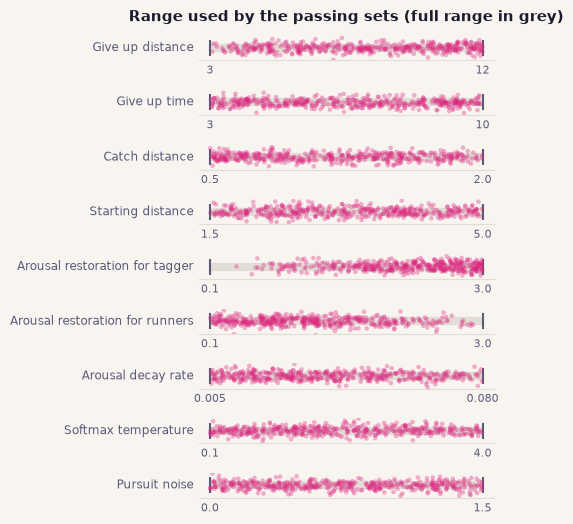

In [6]:
# ── Range coverage: full range in grey, a dot per passing set ───────────────
order = [p for p in SENS_ORDER if p in PARAM_NAMES]
fig, axes = plt.subplots(len(order), 1, figsize=(13 * cm, 1.5 * cm * len(order)),
                         facecolor=BG)
jit = np.random.default_rng(7)
for ax, name in zip(axes, order):
    lo, hi = SWEEP_RANGES[name]
    ax.hlines(0, lo, hi, color=GRID, lw=6, zorder=1)            # allowed range
    ax.plot([lo, hi], [0, 0], marker="|", ls="none", color=MID,
            markersize=11, markeredgewidth=1.5, zorder=2)        # range ends
    ax.scatter(plaus[name], jit.normal(0, 0.18, len(plaus)), s=11,
               color=FUN_C, alpha=0.35, edgecolor="none", zorder=3)
    pad = 0.04 * (hi - lo)
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(-0.6, 0.6)
    ax.set_yticks([])
    ax.set_ylabel(LABELS[name], rotation=0, ha="right", va="center", fontsize=8.5)
    ax.set_xticks([lo, hi]); ax.tick_params(length=0, labelsize=8)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
axes[0].set_title("Range used by the passing sets (full range in grey)",
                  fontsize=11, fontweight="bold", color=DARK, pad=10)
fig.tight_layout()
fig.savefig("ABM_output/fig_range_coverage.png", dpi=300, bbox_inches="tight")
plt.show()

The coverage above shows the plausible region uses almost all of each range, so
the result does not hinge on a narrow corner of parameter space. The matrix below
asks whether passing the plausibility ceiling couples the parameters to each
other. Since they are sampled independently, any correlation here comes either
from the sampling rules (the distance ordering and the tagger restoration above
the runners') or from the ceiling.

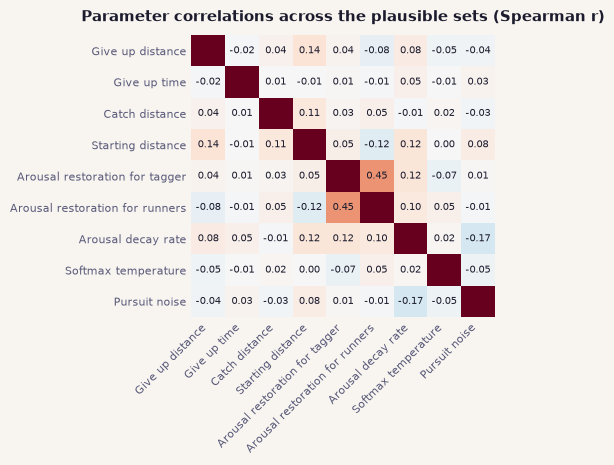

In [7]:
# ── Parameter-parameter correlations across the plausible sets ──────────────
pp = [p for p in SENS_ORDER if p in PARAM_NAMES]
M = np.array([[sp_stats.spearmanr(plaus[a], plaus[b])[0] for b in pp] for a in pp])

fig, ax = plt.subplots(figsize=(13 * cm, 12 * cm), facecolor=BG)
ax.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(pp)))
ax.set_xticklabels([LABELS[p] for p in pp], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(pp)))
ax.set_yticklabels([LABELS[p] for p in pp], fontsize=8)
for i in range(len(pp)):
    for j in range(len(pp)):
        if i == j:
            continue
        v = M[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(v) >= 0.5 else DARK)
for s in ax.spines.values():
    s.set_visible(False)
ax.tick_params(length=0)
ax.set_title("Parameter correlations across the plausible sets (Spearman r)",
             fontsize=11, fontweight="bold", color=DARK, pad=10)
fig.tight_layout()
fig.savefig("ABM_output/fig_param_corr.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. The contrast across the region

Each dot is one parameter set, its FUN tag rate against its WIN tag rate, both
averaged over 100 paired games. The point is not that FUN beats WIN at one
chosen setting, but that it does so across the whole region.

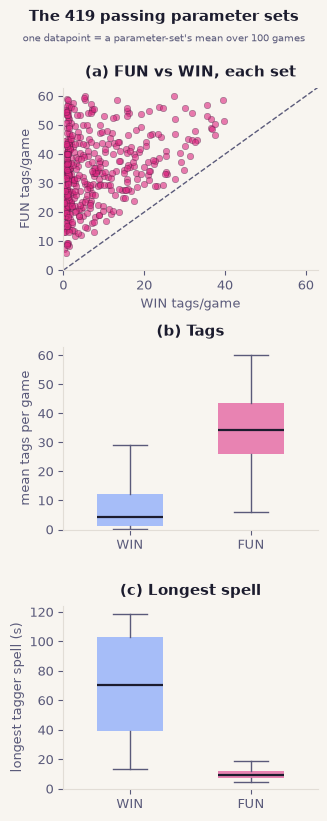

In [8]:
# ── Contrast figure: tags, the FUN vs WIN scatter, and longest spell ────────
def box(ax, groups, positions, colors):
    bp = ax.boxplot(groups, positions=positions, widths=0.55, patch_artist=True,
                    showfliers=False, medianprops=dict(color=DARK, lw=1.6),
                    whiskerprops=dict(color=MID), capprops=dict(color=MID),
                    boxprops=dict(linewidth=0))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color); patch.set_alpha(0.55)

fig, axes = plt.subplots(3, 1, figsize=(8.5 * cm, 21 * cm))

# (a) FUN vs WIN, each set
lim = max(plaus["tags_FUN"].max(), plaus["tags_WIN"].max()) * 1.05
axes[0].plot([0, lim], [0, lim], color=MID, lw=1.0, ls="--")
axes[0].scatter(plaus["tags_WIN"], plaus["tags_FUN"], color=FUN_C, alpha=0.6,
                s=22, edgecolor=DARK, lw=0.3)
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_xlabel("WIN tags/game"); axes[0].set_ylabel("FUN tags/game")
style_ax(axes[0], "(a) FUN vs WIN, each set")

# (b) tags per game, FUN vs WIN
box(axes[1], [plaus["tags_WIN"].values, plaus["tags_FUN"].values],
    [0, 1], [WIN_C, FUN_C])
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["WIN", "FUN"])
axes[1].set_xlim(-0.55, 1.55); axes[1].set_ylim(0, None)
axes[1].set_ylabel("mean tags per game")
style_ax(axes[1], "(b) Tags")

# (c) longest tagger spell, FUN vs WIN
box(axes[2], [plaus["spell_WIN"].values, plaus["spell_FUN"].values],
    [0, 1], [WIN_C, FUN_C])
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(["WIN", "FUN"])
axes[2].set_xlim(-0.55, 1.55); axes[2].set_ylim(0, None)
axes[2].set_ylabel("longest tagger spell (s)")
style_ax(axes[2], "(c) Longest spell")

fig.suptitle(f"The {len(plaus)} passing parameter sets", fontsize=11,
             fontweight="bold", color=DARK, y=0.986)
fig.text(0.5, 0.957, "one datapoint = a parameter-set's mean over 100 games",
         ha="center", va="top", fontsize=7.5, color=MID)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig("ABM_output/fig_contrast.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. What drives the contrast

This is the sensitivity analysis: how each swept parameter relates to the tag
counts across the plausible sets, using Spearman rank correlation, which
captures monotonic main effects and is robust to nonlinearity but does not
capture interactions between parameters. The heatmap and
the ranked list give the overall picture, the scatter grid shows the strongest
relationships up close, and the last panel singles out the chase noise. If WIN
lives mainly on luck, its tags rise with the noise, while FUN, which makes its
own catches, depends instead on how fast arousal drains.

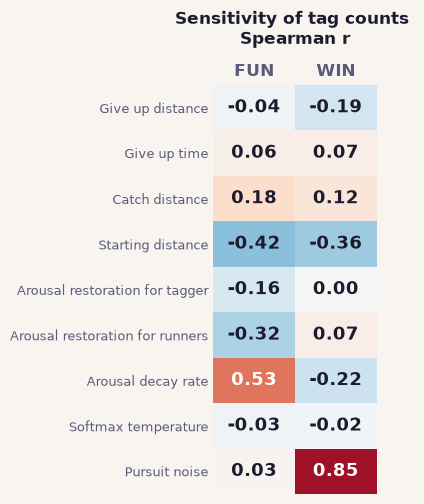

Strongest correlations (Spearman, |r| sorted):
                          param     stat      r
                  Pursuit noise WIN tags  0.847
             Arousal decay rate FUN tags  0.532
              Starting distance FUN tags -0.420
              Starting distance WIN tags -0.362
Arousal restoration for runners FUN tags -0.318
             Arousal decay rate WIN tags -0.217
               Give up distance WIN tags -0.191
                 Catch distance FUN tags  0.177
 Arousal restoration for tagger FUN tags -0.157
                 Catch distance WIN tags  0.120


In [9]:
# ── Sensitivity heatmap: Spearman r of each parameter against the tag counts ─
# Spearman captures monotonic main effects and is robust to nonlinearity; the
# parameters are sampled independently, so each correlation isolates one
# parameter's effect. It does not capture interactions between parameters.
STAT_COLS = ["tags_FUN", "tags_WIN"]
plaus = plaus.copy()
rows = SENS_ORDER

corr_matrix = np.zeros((len(rows), len(STAT_COLS)))
for i, param in enumerate(rows):
    for j, stat in enumerate(STAT_COLS):
        r, _ = sp_stats.spearmanr(plaus[param], plaus[stat])
        corr_matrix[i, j] = r if np.isfinite(r) else 0.0

fig, ax = plt.subplots(figsize=(10 * cm, 13 * cm), facecolor=BG)
ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(STAT_COLS)))
ax.set_xticklabels(["FUN", "WIN"], fontsize=12, fontweight="bold")
ax.xaxis.tick_top()
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([LABELS[p] for p in rows], fontsize=9.5)
for i in range(len(rows)):
    for j in range(len(STAT_COLS)):
        v = corr_matrix[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=13,
                fontweight="bold", color="white" if abs(v) >= 0.5 else DARK)
for s in ax.spines.values():
    s.set_visible(False)
ax.tick_params(length=0)
ax.set_title("Sensitivity of tag counts \nSpearman r", fontsize=12,
             fontweight="bold", color=DARK, pad=14)
fig.tight_layout()
fig.savefig("ABM_output/fig_sensitivity_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Ranked list (code keeps model keys; print uses the friendly labels).
corr_df = pd.DataFrame(
    [{"param": p, "stat": s, "r": corr_matrix[i, j]}
     for i, p in enumerate(rows) for j, s in enumerate(STAT_COLS)])
corr_df = corr_df.reindex(corr_df["r"].abs().sort_values(ascending=False).index)
ranked = corr_df.assign(param=corr_df["param"].map(LABELS),
                        stat=corr_df["stat"].map(STAT_LABELS))
print("Strongest correlations (Spearman, |r| sorted):")
print(ranked.head(10).to_string(index=False, float_format=lambda x: f"{x:6.3f}"))

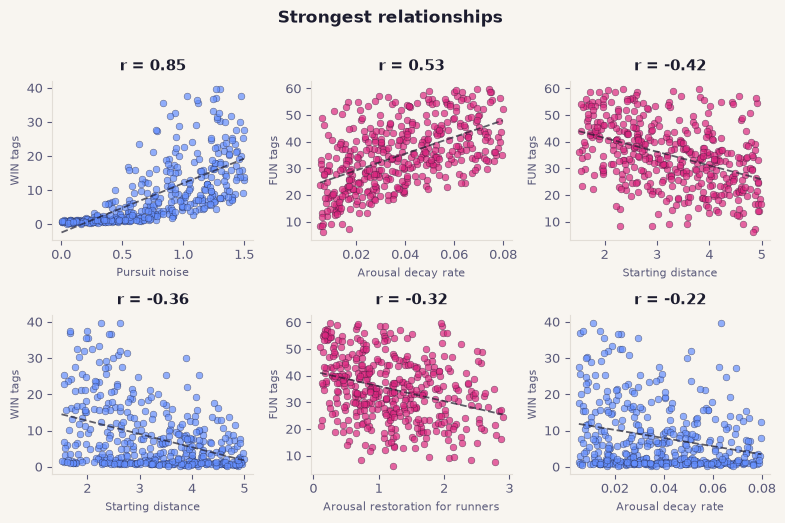

In [10]:
# ── Scatter plots for the strongest pairs ───────────────────────────────────
n_pairs = min(6, len(corr_df)); n_cols = 3
n_rows  = int(np.ceil(n_pairs / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20 * cm, 6.5 * cm * n_rows),
                         facecolor=BG, squeeze=False)
fig.suptitle("Strongest relationships", fontsize=12, fontweight="bold",
             color=DARK, y=1.01)
for idx in range(n_rows * n_cols):
    ax = axes[idx // n_cols][idx % n_cols]
    if idx >= n_pairs:
        ax.set_visible(False); continue
    pair = corr_df.iloc[idx]; param, stat = pair["param"], pair["stat"]
    col = FUN_C if stat == "tags_FUN" else WIN_C
    ax.scatter(plaus[param], plaus[stat], s=24, color=col, edgecolor=DARK,
               linewidth=0.3, alpha=0.7)
    if plaus[param].nunique() > 1:
        slope, intercept = np.polyfit(plaus[param], plaus[stat], 1)
        xs = np.array([plaus[param].min(), plaus[param].max()])
        ax.plot(xs, slope * xs + intercept, color=DARK, lw=1.3, ls="--", alpha=0.7)
    ax.set_xlabel(LABELS[param], fontsize=8); ax.set_ylabel(STAT_LABELS[stat], fontsize=8)
    style_ax(ax, f"r = {pair['r']:.2f}")
plt.tight_layout()
fig.savefig("ABM_output/fig_sensitivity_pairs.png", dpi=300, bbox_inches="tight")
plt.show()

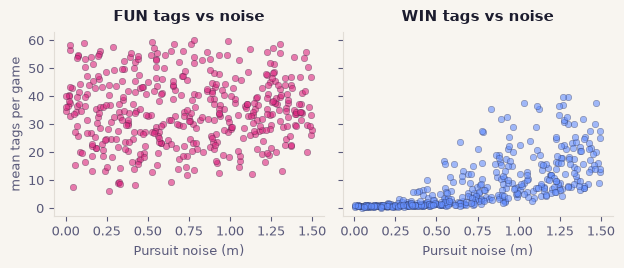

In [11]:
# ── The chase noise: FUN versus WIN ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16 * cm, 7 * cm), sharey=True)
for ax, (stat, col, lab) in zip(axes, [("tags_FUN", FUN_C, "FUN"),
                                       ("tags_WIN", WIN_C, "WIN")]):
    ax.scatter(plaus["PURSUIT_NOISE"], plaus[stat], color=col, alpha=0.6,
               s=22, edgecolor=DARK, lw=0.3)
    ax.set_xlabel("Pursuit noise (m)")
    style_ax(ax, f"{lab} tags vs noise")
axes[0].set_ylabel("mean tags per game")
fig.tight_layout()
fig.savefig("ABM_output/fig_noise_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

A last check, on whether the parameters drive the tag count one at a time or in
combination. The table splits the variance explained (`R^2` from a regression of
tag count on the parameters) into single-parameter effects, each parameter's own
curvature, and pairwise interactions. The bars then rank the interactions that
add the most beyond single-parameter effects, so it is easy to see which
combinations matter. In WIN, where a catch needs several conditions to coincide,
interactions carry far more than in FUN.

Variance in tag counts explained (R^2 of a regression on the parameters):
              main   +curv  +inter     all
FUN           0.81    0.89    0.91    0.96
WIN           0.74    0.77    0.92    0.96

Top interactions for FUN (extra R^2 over main effects):
  +0.024  (+)  Arousal restoration for tagger  x  Arousal restoration for runners
  +0.016  (-)  Arousal restoration for runners  x  Arousal decay rate
  +0.015  (+)  Arousal restoration for runners  x  Pursuit noise
  +0.012  (-)  Give up distance  x  Pursuit noise
  +0.010  (-)  Catch distance  x  Starting distance
  +0.005  (-)  Arousal restoration for tagger  x  Arousal decay rate

Top interactions for WIN (extra R^2 over main effects):
  +0.079  (-)  Starting distance  x  Pursuit noise
  +0.041  (-)  Give up distance  x  Pursuit noise
  +0.014  (-)  Catch distance  x  Starting distance
  +0.011  (+)  Catch distance  x  Pursuit noise
  +0.009  (-)  Arousal decay rate  x  Pursuit noise
  +0.009  (+)  Starting distance  x  Arous

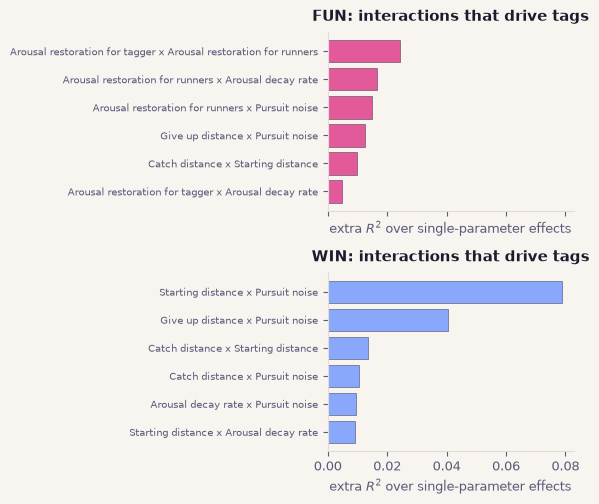

In [12]:
# ── Variance explained: do parameters drive tags singly or in combination? ──
import itertools
pp = [p for p in SENS_ORDER if p in PARAM_NAMES]
n  = len(plaus)
Z  = {p: ((plaus[p] - plaus[p].mean()) / plaus[p].std(ddof=0)).values for p in pp}

def ols_r2(cols, y):
    Xd = np.column_stack([np.ones(n)] + cols)
    beta, *_ = np.linalg.lstsq(Xd, y, rcond=None)
    pred = Xd @ beta
    return 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum(), beta

main_cols = [Z[p] for p in pp]
sq_cols   = [Z[p] ** 2 for p in pp]
pairs     = list(itertools.combinations(pp, 2))
int_cols  = [Z[a] * Z[b] for a, b in pairs]

print("Variance in tag counts explained (R^2 of a regression on the parameters):")
print(f"{'':10}{'main':>8}{'+curv':>8}{'+inter':>8}{'all':>8}")
incr = {}
for cond in ["tags_FUN", "tags_WIN"]:
    y = plaus[cond].values
    r_main, _ = ols_r2(main_cols, y)
    r_curv, _ = ols_r2(main_cols + sq_cols, y)
    r_int,  _ = ols_r2(main_cols + int_cols, y)
    r_all,  _ = ols_r2(main_cols + sq_cols + int_cols, y)
    print(f"{cond.replace('tags_',''):10}{r_main:8.2f}{r_curv:8.2f}{r_int:8.2f}{r_all:8.2f}")
    rows = []
    for (a, b), col in zip(pairs, int_cols):
        r2_one, beta = ols_r2(main_cols + [col], y)
        rows.append((a, b, r2_one - r_main, beta[-1]))   # extra R^2, and its sign
    incr[cond] = sorted(rows, key=lambda r: -r[2])

for cond in ["tags_FUN", "tags_WIN"]:
    print(f"\nTop interactions for {cond.replace('tags_','')} (extra R^2 over main effects):")
    for a, b, d, coef in incr[cond][:6]:
        sign = "+" if coef > 0 else "-"
        print(f"  +{d:.3f}  ({sign})  {LABELS[a]}  x  {LABELS[b]}")

# Bars: which interactions add the most, per condition
fig, axes = plt.subplots(2, 1, figsize=(15 * cm, 13 * cm), sharex=True)
for ax, (cond, col) in zip(axes, [("tags_FUN", FUN_C), ("tags_WIN", WIN_C)]):
    top = incr[cond][:6][::-1]
    ax.barh(range(len(top)), [d for a, b, d, c in top],
            color=col, alpha=0.75, edgecolor=DARK, lw=0.4)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([f"{LABELS[a]} x {LABELS[b]}" for a, b, _, _ in top], fontsize=7.5)
    ax.set_xlabel("extra $R^2$ over single-parameter effects")
    style_ax(ax, f"{cond.replace('tags_','')}: interactions that drive tags")
fig.tight_layout()
fig.savefig("ABM_output/fig_interactions.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. One example game

To show the mechanism in motion, the middle set is played once in each condition
with the same five players, and every agent's arousal and speed is traced over
the two minutes. A typical win game lands very few tags, so for the illustration
we pick a draw whose win game happens to produce three, since with none the
dynamics we want to show are not visible. This is one illustration, not a result;
the argument is the whole region above.

Example game tag counts: {'FUN': 35, 'WIN': 3}


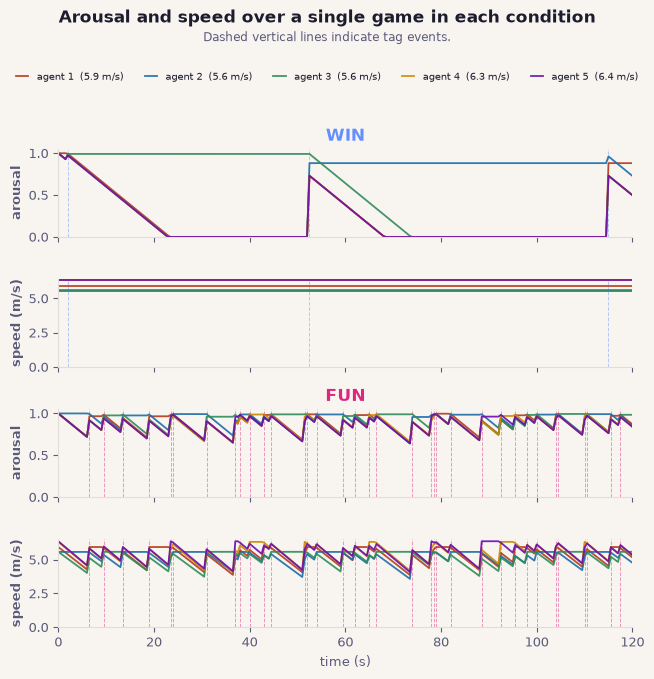


Parameters for the example run (for the figure footnote):
Players = 5; Round = 120 s; Mean speed = 6.0; Sigma speed = 0.50; Condition weight FUN = 1; Condition weight WIN = 0; Master seed = 42; Arousal decay rate = 0.0467; Arousal restoration for runners = 1.31; Arousal restoration for tagger = 2.13; Softmax temperature = 1.61; Starting distance = 2.44; Catch distance = 1.16; Pursuit noise = 0.768; Give up distance = 7.44; Give up time = 5.04


In [13]:
# ── Example game: middle set, a draw whose WIN game lands three tags ────────
REP = dict(FIXED_PARAMS)
for name in PARAM_NAMES:
    REP[name] = float(central_set[name])

# A typical WIN game at this set has very few tags, and with zero the dynamics
# are invisible. Keep the middle (representative) parameter set, but search over
# speed draws for one whose WIN game lands TARGET_WIN_TAGS, for illustration.
TARGET_WIN_TAGS = 3
search = np.random.default_rng(REP["MASTER_SEED"])
best = None
for _ in range(4000):
    speeds = np.clip(search.normal(REP["MU_MAX_SPEED"], REP["SIGMA_MAX_SPEED"],
                                   REP["N_PLAYERS"]), 0.5, None)
    win_seed = int(search.integers(0, 2**31))
    fun_seed = int(search.integers(0, 2**31))
    mw = TagModel(0, "WIN", speeds, REP, win_seed); mw.run()
    wt = len(mw.event_rows) - 1
    if best is None or abs(wt - TARGET_WIN_TAGS) < best[0]:
        best = (abs(wt - TARGET_WIN_TAGS), speeds, win_seed, fun_seed)
    if wt == TARGET_WIN_TAGS:
        break
_, speeds, win_seed, fun_seed = best

games = {}
for cond, seed in [("WIN", win_seed), ("FUN", fun_seed)]:
    m = TagModel(0, cond, speeds, REP, seed); m.run()
    games[cond] = (pd.DataFrame(m.agent_records), pd.DataFrame(m.event_rows))
print("Example game tag counts:",
      {c: len(games[c][1]) - 1 for c in ["FUN", "WIN"]})

# ── One combined figure: four stacked rows, WIN then FUN ────────────────────
panels = [("WIN", "current_arousal_i", "arousal",      (0, 1.05)),
          ("WIN", "current_speed_i",   "speed (m/s)",  (0, None)),
          ("FUN", "current_arousal_i", "arousal",      (0, 1.05)),
          ("FUN", "current_speed_i",   "speed (m/s)",  (0, None))]

fig, axes = plt.subplots(4, 1, figsize=(16.8 * cm, 18 * cm), sharex=True)
for ax, (condition, var, ylab, ylim) in zip(axes, panels):
    ag, ev = games[condition]
    evt = ev[ev["timestamp"] > 0]
    cond_c = COND_STYLE[condition]["color"]
    for pid in sorted(ag["player"].unique()):
        pdta = ag[ag["player"] == pid].sort_values("time")
        ax.plot(pdta["time"], pdta[var], color=P_COLS[(pid - 1) % len(P_COLS)],
                lw=1.3, alpha=0.9, zorder=2,
                label=f"agent {pid}  ({speeds[pid - 1]:.1f} m/s)")
    for t in evt["timestamp"]:
        ax.axvline(t, color=cond_c, lw=0.7, ls="--", alpha=0.45, zorder=1)
    ax.set_ylim(*ylim); ax.set_xlim(0, REP["GAME_DURATION"])
    style_ax(ax)
    ax.set_ylabel(ylab, fontweight="bold")
axes[0].set_title("WIN", fontsize=12, fontweight="bold", color=WIN_C)
axes[2].set_title("FUN", fontsize=12, fontweight="bold", color=FUN_C)
axes[3].set_xlabel("time (s)")

# Legend from the first panel: each agent labelled with its top speed
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, fontsize=7.5,
           frameon=False, bbox_to_anchor=(0.5, 0.905), handlelength=1.2)

fig.suptitle("Arousal and speed over a single game in each condition",
             fontsize=12.5, fontweight="bold", color=DARK, y=0.98)
fig.text(0.5, 0.935, "Dashed vertical lines indicate tag events.",
         ha="center", fontsize=8.5, color=MID)

fig.tight_layout(rect=[0, 0.03, 1, 0.875])
fig.savefig("ABM_output/fig_example.png", dpi=300, bbox_inches="tight")
plt.show()

# Parameter values for this run, printed so they can go in the figure footnote
items = [f"Players = {REP['N_PLAYERS']}", f"Round = {REP['GAME_DURATION']:.0f} s",
         f"Mean speed = {REP['MU_MAX_SPEED']:.1f}", f"Sigma speed = {REP['SIGMA_MAX_SPEED']:.2f}",
         f"Condition weight FUN = {REP['CONDITION_WEIGHT_FUN']:.0f}",
         f"Condition weight WIN = {REP['CONDITION_WEIGHT_WIN']:.0f}",
         f"Master seed = {REP['MASTER_SEED']}"]
items += [f"{LABELS[p]} = {REP[p]:.3g}" for p in PARAM_NAMES]
print("\nParameters for the example run (for the figure footnote):")
print("; ".join(items))

## 7. Taking the luck away

The chase noise is the only source of catches the runners do not make
themselves. Setting it to zero, on the middle set, asks each condition to stand
on its own mechanism: FUN should barely change, WIN should fall toward a stall.

Middle set, mean tags per game:
  noise on   FUN 38.8   WIN 8.64
  noise off  FUN 36.7   WIN 0.92

WIN games ending with a tagger uncaught:
  noise on   25%
  noise off  100%

Longest tagger spell (s):
  noise on   FUN 8.1   WIN 55.1
  noise off  FUN 6.7   WIN 113.4


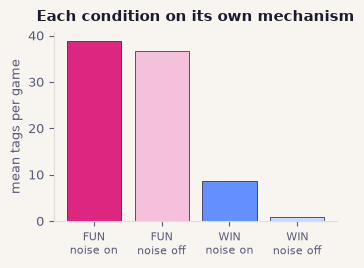

In [14]:
# ── Noise on vs off, middle set, 100 paired games each ──────────────────────
on  = evaluate_set(REP)
off = evaluate_set(REP, pursuit_noise=0.0)

print("Middle set, mean tags per game:")
print(f"  noise on   FUN {on['tags_FUN']:.1f}   WIN {on['tags_WIN']:.2f}")
print(f"  noise off  FUN {off['tags_FUN']:.1f}   WIN {off['tags_WIN']:.2f}")
print()
print("WIN games ending with a tagger uncaught:")
print(f"  noise on   {on['win_stuck_frac']:.0%}")
print(f"  noise off  {off['win_stuck_frac']:.0%}")
print()
print("Longest tagger spell (s):")
print(f"  noise on   FUN {on['spell_FUN']:.1f}   WIN {on['spell_WIN']:.1f}")
print(f"  noise off  FUN {off['spell_FUN']:.1f}   WIN {off['spell_WIN']:.1f}")

fig, ax = plt.subplots(figsize=(9 * cm, 7 * cm))
labels = ["FUN\nnoise on", "FUN\nnoise off", "WIN\nnoise on", "WIN\nnoise off"]
vals   = [on["tags_FUN"], off["tags_FUN"], on["tags_WIN"], off["tags_WIN"]]
cols   = [FUN_C, FUN_L, WIN_C, WIN_L]
ax.bar(range(4), vals, color=cols, edgecolor=DARK, lw=0.5)
ax.set_xticks(range(4)); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("mean tags per game")
style_ax(ax, "Each condition on its own mechanism")
fig.tight_layout()
fig.savefig("ABM_output/fig_noise_off.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ── noise-off across the whole sweep ──────────────────────
# Section 8 turns the pursuit noise off for the middle set only. Here we do it
# for every set: re-evaluate each of the 500 sampled sets with PURSUIT_NOISE = 0,
# all else held fixed and on the same player groups (MASTER_SEED unchanged), so
# each set is its own paired noise-on / noise-off comparison.
print(f"Re-running {len(sweep_df)} sets with noise off "
      f"({N_SIMS} paired games each). Same cost as the main sweep.\n")

rows_off = []
for _, row in sweep_df.iterrows():
    params = dict(FIXED_PARAMS)
    for name in PARAM_NAMES:
        params[name] = float(row[name])
    rec = evaluate_set(params, pursuit_noise=0.0)
    rec["set"] = int(row["set"])
    for name in PARAM_NAMES:
        rec[name] = params[name]
    rows_off.append(rec)
    if len(rows_off) % 50 == 0:
        print(f"  {len(rows_off):4d}/{len(sweep_df)}")

noiseoff_df = pd.DataFrame(rows_off)
noiseoff_df.to_csv("ABM_output/sweep_sets_noiseoff.csv", index=False)
print("\nSaved ABM_output/sweep_sets_noiseoff.csv")

Plausible-on sets: 419

Median [IQR] across these sets:
  tags FUN   noise on     34.44  [  26.07,   43.64]
  tags FUN   noise off    30.44  [  21.52,   40.67]
  tags WIN   noise on      4.26  [   1.17,   12.34]
  tags WIN   noise off     0.74  [   0.53,    0.93]
  spell WIN  noise on     70.59  [  39.26,  103.30]
  spell WIN  noise off   113.92  [ 112.11,  116.03]

  WIN games ending stuck, noise off (median): 100%
  Sets where FUN still > WIN, noise off:      1.000
  Sets where WIN drops below 1 tag/game off:  0.859


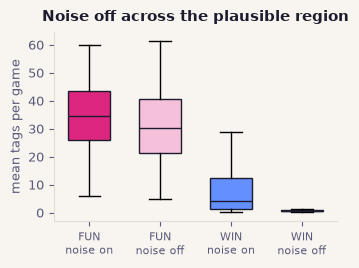

In [19]:
# ── Noise-off sweep: each condition on its own mechanism, across the region ──
# Compared on the sets that were plausible WITH noise on (the calibrated region).
#read csv sweep_sets_noiseoff.csv
noiseoff_df = pd.read_csv("ABM_output/sweep_sets_noiseoff.csv")

on  = sweep_df[sweep_df["plausible"]].set_index("set")
off = noiseoff_df.set_index("set").loc[on.index]

print(f"Plausible-on sets: {len(on)}\n")
print("Median [IQR] across these sets:")
print(f"  tags FUN   noise on   {med_iqr(on['tags_FUN'])}")
print(f"  tags FUN   noise off  {med_iqr(off['tags_FUN'])}")
print(f"  tags WIN   noise on   {med_iqr(on['tags_WIN'])}")
print(f"  tags WIN   noise off  {med_iqr(off['tags_WIN'])}")
print(f"  spell WIN  noise on   {med_iqr(on['spell_WIN'])}")
print(f"  spell WIN  noise off  {med_iqr(off['spell_WIN'])}")
print()
print(f"  WIN games ending stuck, noise off (median): {off['win_stuck_frac'].median():.0%}")
print(f"  Sets where FUN still > WIN, noise off:      {float((off['tags_FUN'] > off['tags_WIN']).mean()):.3f}")
print(f"  Sets where WIN drops below 1 tag/game off:  {float((off['tags_WIN'] < 1).mean()):.3f}")

fig, ax = plt.subplots(figsize=(9 * cm, 7 * cm))
data = [on["tags_FUN"], off["tags_FUN"], on["tags_WIN"], off["tags_WIN"]]
labels = ["FUN\nnoise on", "FUN\nnoise off", "WIN\nnoise on", "WIN\nnoise off"]
bp = ax.boxplot(data, positions=range(4), widths=0.6, showfliers=False,
                patch_artist=True)
for patch, c in zip(bp["boxes"], [FUN_C, FUN_L, WIN_C, WIN_L]):
    patch.set_facecolor(c); patch.set_edgecolor(DARK)
for med in bp["medians"]:
    med.set_color(DARK)
ax.set_xticks(range(4)); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("mean tags per game")
style_ax(ax, "Noise off across the plausible region")
fig.tight_layout()
fig.savefig("ABM_output/fig_noiseoff_sweep.png", dpi=300, bbox_inches="tight")
plt.show()

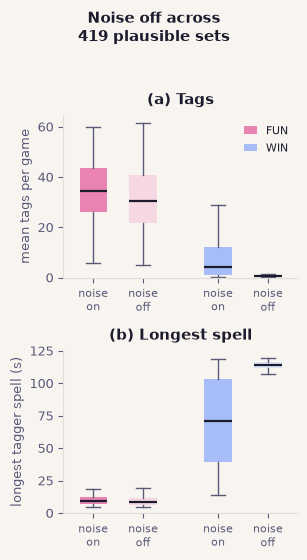

In [20]:
# ── (b) tags and (c) longest spell, noise on vs off, stacked ────────────────
pos   = [0, 1, 2.5, 3.5]
cols  = [FUN_C, FUN_L, WIN_C, WIN_L]
xlabs = ["noise\non", "noise\noff", "noise\non", "noise\noff"]

fig, axes = plt.subplots(2, 1, figsize=(8 * cm, 14 * cm))

box(axes[0],
    [on["tags_FUN"].values, off["tags_FUN"].values,
     on["tags_WIN"].values, off["tags_WIN"].values],
    pos, cols)
axes[0].set_xticks(pos); axes[0].set_xticklabels(xlabs, fontsize=8)
axes[0].set_xlim(-0.6, 4.1); axes[0].set_ylim(0, None)
axes[0].set_ylabel("mean tags per game")
style_ax(axes[0], "(a) Tags")

box(axes[1],
    [on["spell_FUN"].values, off["spell_FUN"].values,
     on["spell_WIN"].values, off["spell_WIN"].values],
    pos, cols)
axes[1].set_xticks(pos); axes[1].set_xticklabels(xlabs, fontsize=8)
axes[1].set_xlim(-0.6, 4.1); axes[1].set_ylim(0, None)
axes[1].set_ylabel("longest tagger spell (s)")
style_ax(axes[1], "(b) Longest spell")

# Legend: condition colour (shade light/dark = noise off/on, shown on the x-axis)
legend_handles = [
    mpatches.Patch(facecolor=FUN_C, alpha=0.55, label="FUN"),
    mpatches.Patch(facecolor=WIN_C, alpha=0.55, label="WIN"),
]
axes[0].legend(handles=legend_handles, loc="upper right", frameon=False,
               fontsize=8, handlelength=1.2)

fig.suptitle(f"Noise off across\n{len(on)} plausible sets", fontsize=11,
             fontweight="bold", color=DARK, y=1.005)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig("ABM_output/fig_noiseoff_sweep.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Does WIN ever beat FUN in a single game?

The contrast above compares per-set means. A stricter question is whether even a
single paired game, with the same parameters and the same players, ever lands
more tags in win than in fun. The sweep stored only the means, so the cell below
replays every plausible set's 100 paired games and counts them. It re-runs the
games, so it takes a few minutes.

In [ ]:
# # ── Replay plausible sets game by game and compare WIN vs FUN per pair ──────
# # Draw order matches evaluate_set exactly (speeds, then FUN seed, then WIN seed),
# # so these are the same games the sweep evaluated. Set plaus -> sweep_df to also
# # include the discarded sets.
# n_pairs = win_gt_fun = win_eq_fun = 0
# for i, (_, row) in enumerate(plaus.iterrows()):
#     params = dict(FIXED_PARAMS)
#     for nm in PARAM_NAMES:
#         params[nm] = float(row[nm])
#     rng = np.random.default_rng(params["MASTER_SEED"])
#     for _ in range(N_SIMS):
#         speeds = np.clip(rng.normal(params["MU_MAX_SPEED"], params["SIGMA_MAX_SPEED"],
#                                     params["N_PLAYERS"]), 0.5, None)
#         fun_seed = int(rng.integers(0, 2**31))
#         win_seed = int(rng.integers(0, 2**31))
#         mf = TagModel(0, "FUN", speeds, params, fun_seed); mf.run()
#         mw = TagModel(0, "WIN", speeds, params, win_seed); mw.run()
#         ft = len(mf.event_rows) - 1
#         wt = len(mw.event_rows) - 1
#         n_pairs += 1
#         if wt > ft:  win_gt_fun += 1
#         if wt == ft: win_eq_fun += 1
#     if (i + 1) % 50 == 0:
#         print(f"  ...{i + 1}/{len(plaus)} sets;  WIN > FUN so far: {win_gt_fun}")

# print(f"\nPaired games compared: {n_pairs:,}")
# print(f"  WIN tags >  FUN tags: {win_gt_fun}  ({100 * win_gt_fun / n_pairs:.3f}%)")
# print(f"  WIN tags == FUN tags: {win_eq_fun}  ({100 * win_eq_fun / n_pairs:.3f}%)")
# print(f"  WIN tags <  FUN tags: {n_pairs - win_gt_fun - win_eq_fun}")

KeyboardInterrupt: 

9. What if everyone had the same speed?

Middle set, 200 paired games, mean tags per game:
  drawn speeds   FUN  38.8   WIN  8.63   (gap 30.2)
  equal speeds   FUN  44.1   WIN 15.41   (gap 28.7)

FUN runner speed share (equal speeds): 0.90
WIN games ending stuck (equal speeds): 4%


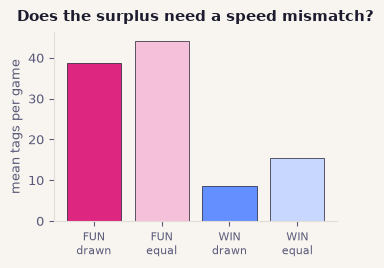


Longest tagger spell (s):
  drawn speeds   FUN 8.1   WIN 54.6
  equal speeds   FUN 6.7   WIN 25.9


In [22]:
# ── Equal-speed check: does the FUN surplus need a speed mismatch? ───────────
# Objection: the tagger mostly catches the intrinsically slowest runner, so the
# surplus could be an artefact of mismatched players, and real children pick
# well-matched partners. Remove all speed heterogeneity: fix every agent to the
# mean (SIGMA_MAX_SPEED = 0) at the middle set, so the only catchable gaps in
# FUN are the ones self-handicapping creates, and WIN keeps only the noise.
N_EQUAL = 200

het = evaluate_set(REP, n_sims=N_EQUAL)                      # drawn speeds, baseline
REP_equal = dict(REP); REP_equal["SIGMA_MAX_SPEED"] = 0.0
equal = evaluate_set(REP_equal, n_sims=N_EQUAL)             # all agents at the mean

print(f"Middle set, {N_EQUAL} paired games, mean tags per game:")
print(f"  drawn speeds   FUN {het['tags_FUN']:5.1f}   WIN {het['tags_WIN']:5.2f}"
      f"   (gap {het['tags_FUN'] - het['tags_WIN']:.1f})")
print(f"  equal speeds   FUN {equal['tags_FUN']:5.1f}   WIN {equal['tags_WIN']:5.2f}"
      f"   (gap {equal['tags_FUN'] - equal['tags_WIN']:.1f})")
print(f"\nFUN runner speed share (equal speeds): {equal['speed_share_FUN']:.2f}")
print(f"WIN games ending stuck (equal speeds): {equal['win_stuck_frac']:.0%}")

fig, ax = plt.subplots(figsize=(9 * cm, 7 * cm))
labels = ["FUN\ndrawn", "FUN\nequal", "WIN\ndrawn", "WIN\nequal"]
vals   = [het["tags_FUN"], equal["tags_FUN"], het["tags_WIN"], equal["tags_WIN"]]
cols   = [FUN_C, FUN_L, WIN_C, WIN_L]
ax.bar(range(4), vals, color=cols, edgecolor=DARK, lw=0.5)
ax.set_xticks(range(4)); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("mean tags per game")
style_ax(ax, "Does the surplus need a speed mismatch?")
fig.tight_layout()
fig.savefig("ABM_output/fig_equal_speed.png", dpi=300, bbox_inches="tight")
plt.show()
print("\nLongest tagger spell (s):")
print(f"  drawn speeds   FUN {het['spell_FUN']:.1f}   WIN {het['spell_WIN']:.1f}")
print(f"  equal speeds   FUN {equal['spell_FUN']:.1f}   WIN {equal['spell_WIN']:.1f}")